# Two-Tower Data Preparation — Output Showcase

This notebook reads the Parquet files written by `01_data_prep.py` and explores the output: schema, distributions, sample rows, and key quality checks.

**Data location:** `gs://nshen7-personal-bucket/projects/rec_sys_goodreads/data/two_tower_splits/`  
**Splits:** `train` (30.5 M rows) · `val` (8.7 M rows) · `test` (4.3 M rows) · `confirmed_negatives` (is_read=1, rating∈{1,2}; training users/items only)

## 0. Configuration

In [1]:
GCS_SPLITS = "gs://nshen7-personal-bucket/projects/rec_sys_goodreads/data/two_tower_splits"
HISTORY_LENGTH = 10
TOP_SHELVES = 3

## 1. Start Spark

In [2]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

spark = (
    SparkSession.builder
    .appName("two_tower_output_showcase")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
print(f"Spark {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/26 22:34:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1


## 2. Load Splits

In [3]:
train = spark.read.parquet(f"{GCS_SPLITS}/train")
val   = spark.read.parquet(f"{GCS_SPLITS}/val")
test  = spark.read.parquet(f"{GCS_SPLITS}/test")
confirmed_negatives = spark.read.parquet(f"{GCS_SPLITS}/confirmed_negatives")

n_train = train.count()
n_val   = val.count()
n_test  = test.count()
n_total = n_train + n_val + n_test
n_conf_neg = confirmed_negatives.count()

print(f"train               : {n_train:>12,}  ({n_train/n_total*100:.1f}%)")
print(f"val                 : {n_val:>12,}  ({n_val/n_total*100:.1f}%)")
print(f"test                : {n_test:>12,}  ({n_test/n_total*100:.1f}%)")
print(f"total (positives)   : {n_total:>12,}")
print(f"confirmed_negatives : {n_conf_neg:>12,}")

train               :   29,683,247  (70.1%)
val                 :    8,450,964  (19.9%)
test                :    4,230,805  (10.0%)
total (positives)   :   42,365,016
confirmed_negatives :      306,474


## 3. Schema

In [4]:
train.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- target_item_id: integer (nullable = true)
 |-- history_item_ids: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- history_item_weights: array (nullable = true)
 |    |-- element: float (containsNull = true)
 |-- sample_weight: double (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- is_read: integer (nullable = true)
 |-- rating: integer (nullable = true)
 |-- book_avg_rating: float (nullable = true)
 |-- book_ratings_count: integer (nullable = true)
 |-- book_language: string (nullable = true)
 |-- book_format: string (nullable = true)
 |-- book_num_pages: integer (nullable = true)
 |-- book_publication_year: integer (nullable = true)
 |-- book_is_ebook: integer (nullable = true)
 |-- book_primary_author_id: string (nullable = true)
 |-- book_top_shelves: array (nullable = true)
 |    |-- element: string (containsNull = true)



## 4. Sample Rows

Five rows from the training set — each row is one training example.

In [5]:
(
    train
    .select(
        "user_id", "target_item_id",
        "history_item_ids", "history_item_weights",
        "sample_weight", "timestamp",
        "is_read", "rating",
    )
    .limit(5)
    .toPandas()
)

,user_id,target_item_id,history_item_ids,history_item_weights,sample_weight,timestamp,is_read,rating
0,1580,438,"[1190, 21164, 14067, 14078, 12952, 17278, 1063...","[3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 4.0, ...",5.0,2012-06-10 05:29:54,1,5
1,37146,438,"[139553, 73052, 74028, 140029, 411739, 74118, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0,2017-08-06 20:04:10,0,0
2,37526,438,"[67062, 12799, 48374, 6832, 634, 100, 787, 704...","[5.0, 5.0, 5.0, 5.0, 3.0, 4.0, 4.0, 5.0, 5.0, ...",5.0,2016-03-08 03:49:22,1,5
3,51595,438,"[939, 461, 1386, 1011, 1201, 828, 66, 1116, 11...","[5.0, 1.0, 5.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",1.0,2013-12-20 01:51:46,0,0
4,87462,438,"[459, 943, 586, 772, 547, 839, 941, 670, 1041,...","[4.0, 5.0, 5.0, 4.0, 3.0, 4.0, 5.0, 4.0, 5.0, ...",4.0,2013-02-26 21:27:48,1,4


In [6]:
# Book-feature columns for the same 5 rows
(
    train
    .select(
        "target_item_id",
        "book_avg_rating", "book_ratings_count",
        "book_language", "book_format",
        "book_num_pages", "book_publication_year",
        "book_is_ebook", "book_primary_author_id",
        "book_top_shelves",
    )
    .limit(5)
    .toPandas()
)

,target_item_id,book_avg_rating,book_ratings_count,book_language,book_format,book_num_pages,book_publication_year,book_is_ebook,book_primary_author_id,book_top_shelves
0,438,4.37,720582,eng,Hardcover,64,1964,0,435477,"[to-read, favorites, childrens]"
1,438,4.37,720582,eng,Hardcover,64,1964,0,435477,"[to-read, favorites, childrens]"
2,438,4.37,720582,eng,Hardcover,64,1964,0,435477,"[to-read, favorites, childrens]"
3,438,4.37,720582,eng,Hardcover,64,1964,0,435477,"[to-read, favorites, childrens]"
4,438,4.37,720582,eng,Hardcover,64,1964,0,435477,"[to-read, favorites, childrens]"


## 5. User & Item Coverage per Split

In [7]:
coverage = []
for name, df in [("train", train), ("val", val), ("test", test)]:
    n_users = df.select("user_id").distinct().count()
    n_items = df.select("target_item_id").distinct().count()
    coverage.append({"split": name, "unique_users": n_users, "unique_items": n_items})

pd.DataFrame(coverage).set_index("split")

,unique_users,unique_items
split,,
train,161247,738246
val,161234,667614
test,161162,528878


## 6. Sample-Weight Distribution (train)

Formula: `r = 1*is_shelved + 2*is_read + 1.0*max(0, rating − 3)`

Note: rows with `is_read=1, rating∈{1,2}` are excluded from the positive splits and written separately to `confirmed_negatives/`. So `sample_weight=3.0` here covers only `is_read=1, rating∈{0,3}`.

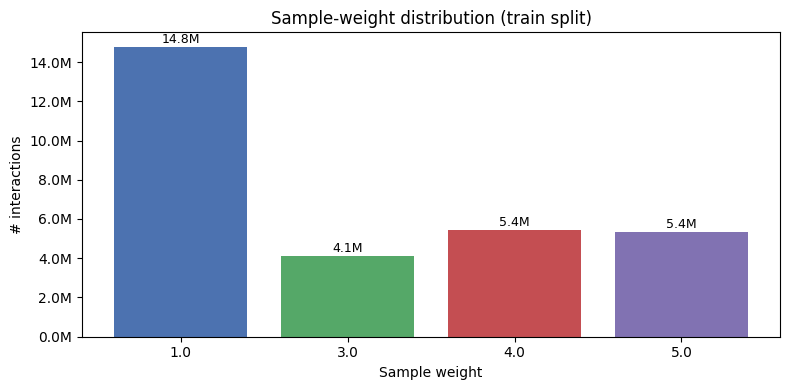

,sample_weight,count
0,1.0,14774096
1,3.0,4114291
2,4.0,5433620
3,5.0,5361240


In [8]:
sw_df = (
    train
    .groupBy("sample_weight")
    .count()
    .orderBy("sample_weight")
    .toPandas()
)

# Label mapping
label_map = {
    1.0: "1.0\n(unread, no rating)",
    3.0: "3.0\n(read, no/low rating)",
    4.0: "4.0\n(read, rating=4)",
    5.0: "5.0\n(read, rating=5)",
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    sw_df["sample_weight"].astype(str),
    sw_df["count"],
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"],
)
ax.set_xlabel("Sample weight")
ax.set_ylabel("# interactions")
ax.set_title("Sample-weight distribution (train split)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, row in zip(bars, sw_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5e4,
            f"{row.count/1e6:.1f}M", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

sw_df

## 6b. Confirmed Negatives Inspection

Schema and rating breakdown of the `confirmed_negatives/` table.

In [9]:
confirmed_negatives.printSchema()

# Rating breakdown (should only be 1 and 2)
confirmed_negatives.groupBy("rating").count().orderBy("rating").show()

# User/item coverage
n_users_neg = confirmed_negatives.select("user_id").distinct().count()
n_items_neg = confirmed_negatives.select("item_id").distinct().count()
print(f"Unique users with confirmed negatives: {n_users_neg:,}")
print(f"Unique items appearing as confirmed negatives: {n_items_neg:,}")
print(f"Avg confirmed negatives per user: {n_conf_neg / n_users_neg:.1f}")

root
 |-- item_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- rating: integer (nullable = true)



+------+------+
|rating| count|
+------+------+
|     1| 75563|
|     2|230911|
+------+------+



Unique users with confirmed negatives: 22,576
Unique items appearing as confirmed negatives: 109,432
Avg confirmed negatives per user: 13.6


## 7. Timestamp (Temporal Coverage) per Split

In [10]:
ts_rows = []
for name, df in [("train", train), ("val", val), ("test", test)]:
    row = df.select(
        F.min("timestamp").alias("earliest"),
        F.max("timestamp").alias("latest"),
    ).collect()[0]
    ts_rows.append({"split": name, "earliest": row["earliest"], "latest": row["latest"]})

ts_pd = pd.DataFrame(ts_rows).set_index("split")
print(ts_pd.to_string())
print("\nNote: global overlap is expected — splits are ordered per-user, not globally.")

                 earliest              latest
split                                        
train 1999-01-07 08:00:00 2017-11-04 04:12:20
val   2007-02-02 07:16:56 2017-11-04 04:23:02
test  2007-02-02 07:22:48 2017-11-04 06:56:23

Note: global overlap is expected — splits are ordered per-user, not globally.


## 8. User Interaction-Count Distribution (train)

How many interactions does each user have in the training split?

count    161247.000000
mean        184.085577
std         533.391029
min           3.000000
25%          28.000000
50%          75.000000
75%         188.000000
95%         660.000000
99%        1607.000000
max       60893.000000


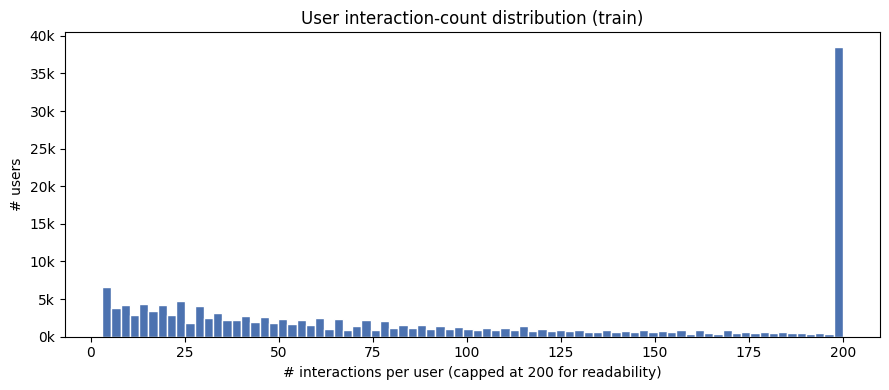

In [11]:
user_counts_pd = (
    train
    .groupBy("user_id")
    .count()
    .select("count")
    .toPandas()
)

stats = user_counts_pd["count"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
print(stats.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(user_counts_pd["count"].clip(upper=200), bins=80, color="#4C72B0", edgecolor="white")
ax.set_xlabel("# interactions per user (capped at 200 for readability)")
ax.set_ylabel("# users")
ax.set_title("User interaction-count distribution (train)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()

## 9. History Array Inspection

Verify every row has exactly `HISTORY_LENGTH` entries and inspect padding.

In [12]:
print(f"Expected history length: {HISTORY_LENGTH}")
for name, df in [("train", train), ("val", val), ("test", test)]:
    wrong = df.filter(F.size("history_item_ids") != HISTORY_LENGTH).count()
    status = "OK" if wrong == 0 else f"FAIL — {wrong:,} bad rows"
    print(f"  {name}: array length check  [{status}]")

Expected history length: 10


  train: array length check  [OK]


  val: array length check  [OK]


  test: array length check  [OK]


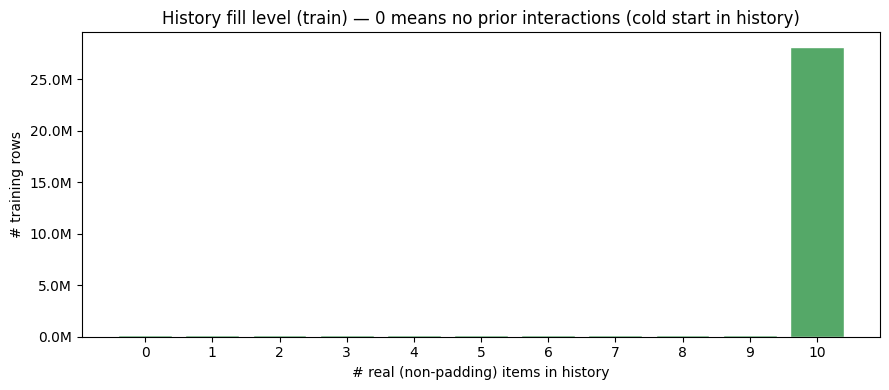

,n_real,count
0,0,161247
1,1,161247
2,2,161247
3,3,159288
4,4,155991
5,5,154572
6,6,153269
7,7,150786
8,8,149679
9,9,147629


In [13]:
# Distribution of non-zero (real) entries vs. padding zeros in history_item_ids (train)
real_count_pd = (
    train
    .withColumn(
        "n_real",
        F.size(F.filter(F.col("history_item_ids"), lambda x: x != 0)),
    )
    .groupBy("n_real")
    .count()
    .orderBy("n_real")
    .toPandas()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(real_count_pd["n_real"], real_count_pd["count"], color="#55A868", edgecolor="white")
ax.set_xlabel("# real (non-padding) items in history")
ax.set_ylabel("# training rows")
ax.set_title("History fill level (train) — 0 means no prior interactions (cold start in history)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_xticks(range(HISTORY_LENGTH + 1))
plt.tight_layout()
plt.show()

real_count_pd

## 10. Book Feature Coverage

In [14]:
book_feature_cols = [
    "book_avg_rating", "book_ratings_count",
    "book_language", "book_format",
    "book_num_pages", "book_publication_year",
    "book_is_ebook", "book_primary_author_id",
]

null_counts = (
    train
    .select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in book_feature_cols])
    .collect()[0]
    .asDict()
)

coverage_rows = [
    {"column": col, "null_count": null_counts[col],
     "null_pct": null_counts[col] / n_train * 100}
    for col in book_feature_cols
]
pd.DataFrame(coverage_rows).set_index("column").style.format({"null_pct": "{:.2f}%"})

,null_count,null_pct
column,,
book_avg_rating,805,0.00%
book_ratings_count,805,0.00%
book_language,0,0.00%
book_format,0,0.00%
book_num_pages,2570622,8.66%
book_publication_year,4360531,14.69%
book_is_ebook,0,0.00%
book_primary_author_id,805,0.00%


## 11. Book Language Distribution (top 15, train)

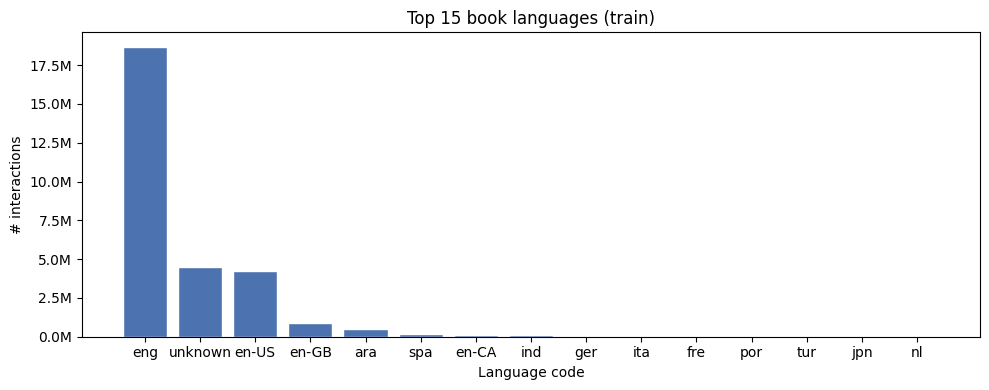

,book_language,count
0,eng,18679551
1,unknown,4496815
2,en-US,4206419
3,en-GB,863543
4,ara,486867
5,spa,158777
6,en-CA,137590
7,ind,83061
8,ger,75632
9,ita,74018


In [15]:
lang_pd = (
    train
    .groupBy("book_language")
    .count()
    .orderBy(F.desc("count"))
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lang_pd["book_language"], lang_pd["count"], color="#4C72B0", edgecolor="white")
ax.set_xlabel("Language code")
ax.set_ylabel("# interactions")
ax.set_title("Top 15 book languages (train)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

lang_pd

## 12. Top Shelf Tags Distribution (train)

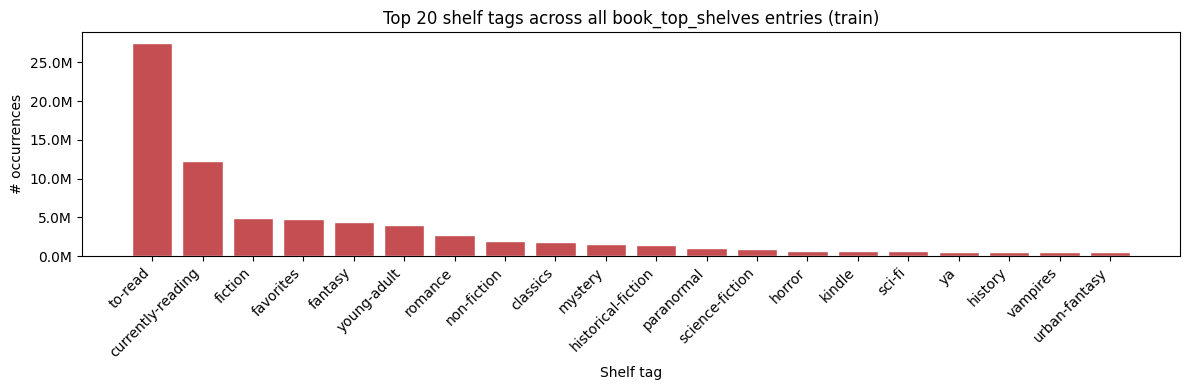

,shelf,count
0,to-read,27499702
1,currently-reading,12332792
2,fiction,4944788
3,favorites,4758633
4,fantasy,4369246
5,young-adult,3998187
6,romance,2718333
7,non-fiction,1911718
8,classics,1856207
9,mystery,1611212


In [16]:
shelf_pd = (
    train
    .select(F.explode("book_top_shelves").alias("shelf"))
    .filter(F.col("shelf") != "")   # drop padding
    .groupBy("shelf")
    .count()
    .orderBy(F.desc("count"))
    .limit(20)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(shelf_pd["shelf"], shelf_pd["count"], color="#C44E52", edgecolor="white")
ax.set_xlabel("Shelf tag")
ax.set_ylabel("# occurrences")
ax.set_title("Top 20 shelf tags across all book_top_shelves entries (train)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

shelf_pd

## 13. Rating Distribution (train)

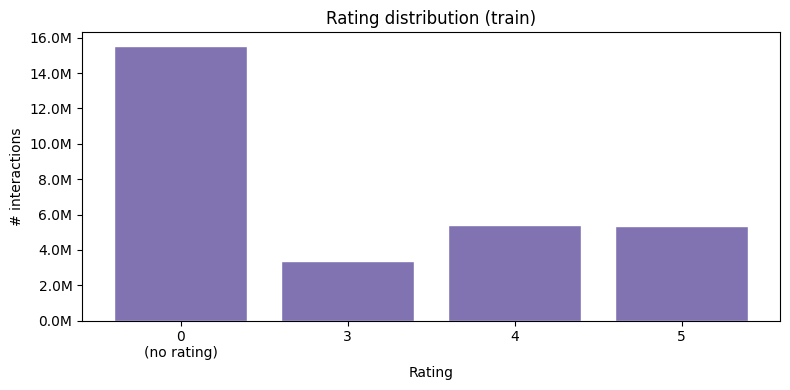

,rating,count
0,0,15533383
1,3,3355004
2,4,5433620
3,5,5361240


In [17]:
rating_pd = (
    train
    .groupBy("rating")
    .count()
    .orderBy("rating")
    .toPandas()
)

labels = {0: "0\n(no rating)", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5"}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    [labels.get(r, str(r)) for r in rating_pd["rating"]],
    rating_pd["count"],
    color="#8172B2", edgecolor="white",
)
ax.set_xlabel("Rating")
ax.set_ylabel("# interactions")
ax.set_title("Rating distribution (train)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

rating_pd

## 14. is_read Distribution (train)

In [18]:
is_read_pd = (
    train
    .groupBy("is_read")
    .count()
    .orderBy("is_read")
    .toPandas()
)
is_read_pd["label"] = is_read_pd["is_read"].map({0: "not read", 1: "read"})
is_read_pd[["label", "count"]].assign(pct=lambda d: d["count"] / d["count"].sum() * 100)

,label,count,pct
0,not read,14774096,49.772506
1,read,14909151,50.227494


## 15. Publication Year Distribution (train)

In [19]:
print("=" * 55)
print("PIPELINE OUTPUT SUMMARY")
print("=" * 55)
print(f"Total rows (positives) : {n_total:>12,}")
print(f"  train                : {n_train:>12,}  ({n_train/n_total*100:.1f}%)")
print(f"  val                  : {n_val:>12,}  ({n_val/n_total*100:.1f}%)")
print(f"  test                 : {n_test:>12,}  ({n_test/n_total*100:.1f}%)")
print(f"confirmed_negatives    : {n_conf_neg:>12,}")
print()
print(f"History length         : {HISTORY_LENGTH}  (padded with 0)")
print(f"Book feature columns   : {len(book_feature_cols)}")
print(f"Top shelf tags kept    : {TOP_SHELVES}  (padded with '')")
print("=" * 55)

PIPELINE OUTPUT SUMMARY
Total rows (positives) :   42,365,016
  train                :   29,683,247  (70.1%)
  val                  :    8,450,964  (19.9%)
  test                 :    4,230,805  (10.0%)
confirmed_negatives    :      306,474

History length         : 10  (padded with 0)
Book feature columns   : 8
Top shelf tags kept    : 3  (padded with '')


## 16. Summary

In [20]:
print("=" * 55)
print("PIPELINE OUTPUT SUMMARY")
print("=" * 55)
print(f"Total rows : {n_total:>12,}")
print(f"  train    : {n_train:>12,}  ({n_train/n_total*100:.1f}%)")
print(f"  val      : {n_val:>12,}  ({n_val/n_total*100:.1f}%)")
print(f"  test     : {n_test:>12,}  ({n_test/n_total*100:.1f}%)")
print()
print(f"History length         : {HISTORY_LENGTH}  (padded with 0)")
print(f"Book feature columns   : {len(book_feature_cols)}")
print(f"Top shelf tags kept    : {TOP_SHELVES}  (padded with '')")
print("=" * 55)

PIPELINE OUTPUT SUMMARY
Total rows :   42,365,016
  train    :   29,683,247  (70.1%)
  val      :    8,450,964  (19.9%)
  test     :    4,230,805  (10.0%)

History length         : 10  (padded with 0)
Book feature columns   : 8
Top shelf tags kept    : 3  (padded with '')


In [21]:
spark.stop()